# 지하철 이용현황
- https://data.busan.go.kr/
- 
승하차 인원정보  
- 일별역별시간대별승하차20260604 파일받기
- 
-https://data.busan.go.kr/bdip/opendata/dataSet.do?searchKeyword=%EC%9D%BC%EB%B3%84&searchOption=OR&=

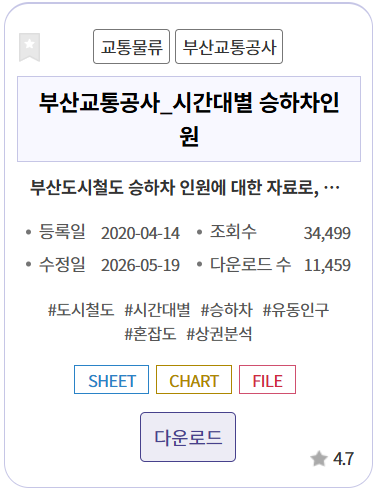OR&

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Text(0.2, 0.4, '한글')

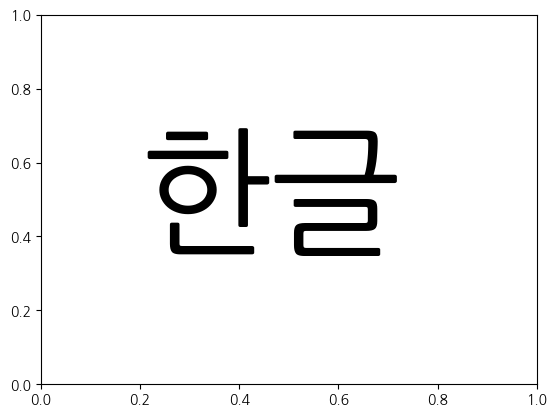

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [19]:
df.columns

Index(['name', 'date', 'week', 'type', 'total'], dtype='str')

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = './dataset/일별역별시간대별승하차202604.csv'
df = pd.read_csv(file_path, encoding="EUC-KR")
df[df['역명'] == '경성대부경대']

,역번호,역명,년월일,요일,구분,합계,01시-02시,02시-03시,03시-04시,04시-05시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시-01시
3162,212,경성대부경대,2026-01-01,목,승차,7668,0,0,0,6,...,567,676,605,485,350,341,312,234,132,11
3163,212,경성대부경대,2026-01-01,목,하차,7722,0,0,0,0,...,542,586,584,615,494,379,529,428,259,79
3164,212,경성대부경대,2026-01-02,금,승차,14210,0,0,0,1,...,1108,1216,1323,1403,716,595,504,421,266,14
3165,212,경성대부경대,2026-01-02,금,하차,14807,0,0,0,0,...,886,1020,1276,1931,983,608,649,603,379,84
3166,212,경성대부경대,2026-01-03,토,승차,11382,0,0,0,1,...,947,1108,998,736,529,465,395,353,225,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23275,212,경성대부경대,2026-04-28,화,하차,23411,0,0,0,1,...,945,1176,1501,2150,977,743,762,810,345,115
23276,212,경성대부경대,2026-04-29,수,승차,22434,0,0,0,0,...,1781,2648,2718,2024,960,848,738,591,414,13
23277,212,경성대부경대,2026-04-29,수,하차,22814,3,0,0,0,...,947,1156,1501,2110,1001,770,710,720,559,94
23278,212,경성대부경대,2026-04-30,목,승차,25420,0,0,0,3,...,2015,3005,3147,2484,1196,1031,948,676,399,13


In [3]:
columns = ['num', 'name', 'date', 'week', 'type', 'total'] 
time_col = [f'{i:02}~{i+1:02}H' for i in range(1,24)]
last_col = ['24~01H']
columns= columns + time_col + last_col
df.columns = columns
df = df.loc[:,'name':'total']
df

,name,date,week,type,total
0,다대포해수욕장,2026-01-01,목,승차,7526
1,다대포해수욕장,2026-01-01,목,하차,7357
2,다대포해수욕장,2026-01-02,금,승차,4135
3,다대포해수욕장,2026-01-02,금,하차,3177
4,다대포해수욕장,2026-01-03,토,승차,4114
...,...,...,...,...,...
26875,안평,2026-04-28,화,하차,2177
26876,안평,2026-04-29,수,승차,2260
26877,안평,2026-04-29,수,하차,2171
26878,안평,2026-04-30,목,승차,2287


In [4]:
data = df.groupby(['name','date']).sum().reset_index()
gdata = data[['name', 'date', 'total']]
gdata

,name,date,total
0,가야,2026-01-01,4052
1,가야,2026-01-02,6863
2,가야,2026-01-03,5731
3,가야,2026-01-04,4291
4,가야,2026-01-05,7529
...,...,...,...
12955,화명,2026-04-26,13611
12956,화명,2026-04-27,24651
12957,화명,2026-04-28,25796
12958,화명,2026-04-29,25204


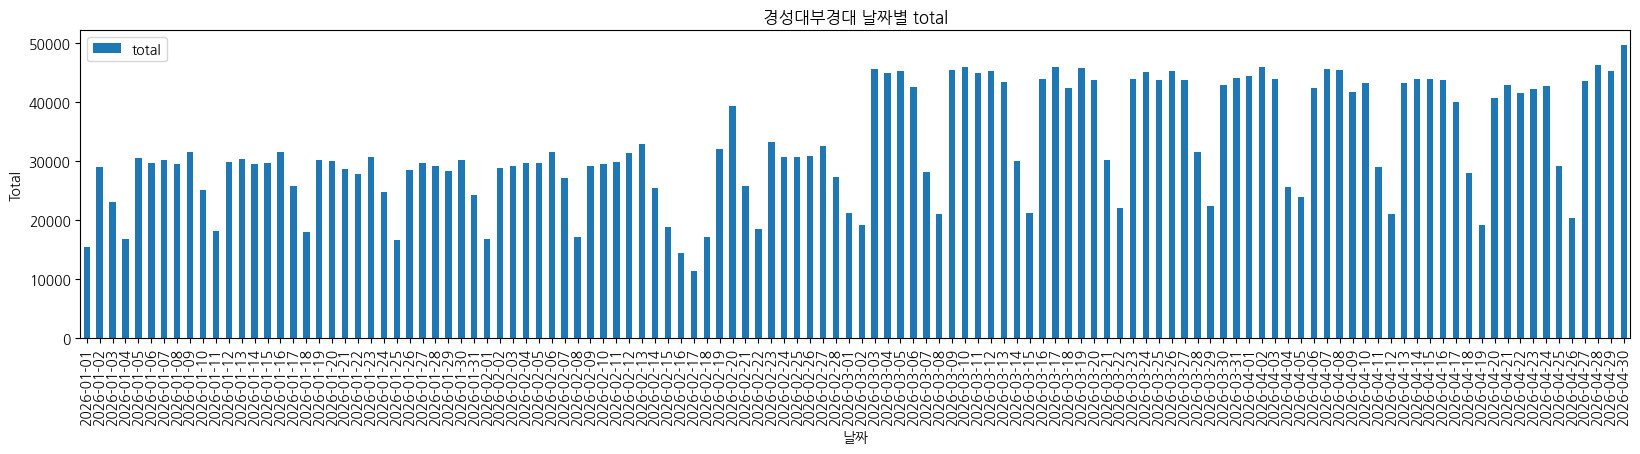

In [5]:
pknu = gdata[gdata['name'] == '경성대부경대']

pknu.plot(
    x='date',
    y='total',
    kind='bar',
    figsize=(20,4),
    title='경성대부경대 날짜별 total'
)
plt.xlabel("날짜")
plt.ylabel("Total")
plt.show()

In [6]:
mdata = gdata.groupby('name').sum().reset_index()
tdata = mdata[['name','total']]
tdata

,name,total
0,가야,859904
1,감전,945880
2,강서구청,743507
3,개금,1977368
4,거제,1407286
...,...,...
103,토성,2133902
104,하단,4438206
105,해운대,3565397
106,호포,303301


In [7]:
total = tdata.sort_values('total', ascending=False)
total = total.head(20)
total

,name,total
70,서면,15442639
83,연산,6546162
61,부산역,5854705
65,사상,5529064
72,센텀시티,4971878
36,동래,4759891
23,남포,4453665
104,하단,4438206
88,자갈치,4340249
33,덕천,4305480


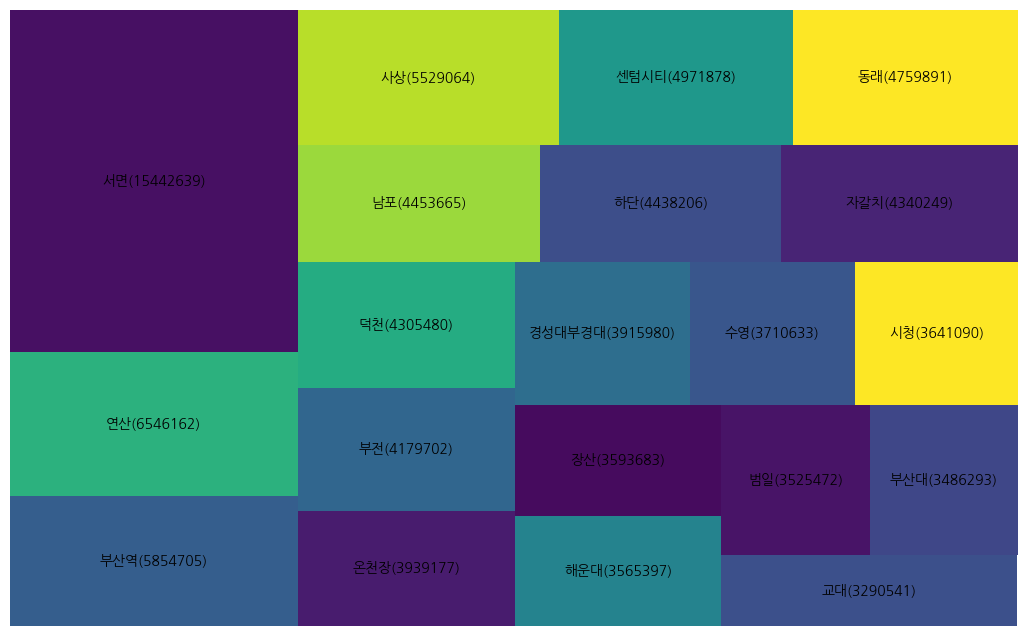

In [8]:
import squarify as sq
plt.figure(figsize=(13,8))
sq.plot(sizes=total['total'], label = [f"{n}({t})" for n, t in zip(total['name'],total['total'])])
plt.rcParams['font.size'] = 10
plt.rcParams['text.color'] = 'white'
plt.gca().invert_yaxis()  # y축 뒤집기
plt.axis('off')  # 축 인덱스 끄기
plt.show()

### 서울 2호선으로 정리해보세요

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = './dataset/서울시지하철호선별역별승하차인원정보.csv'
se = pd.read_csv(file_path, encoding="EUC-KR")
se[se['호선명'] == '2호선']

,사용일자,호선명,역명,승차총승객수,하차총승객수,등록일자
13,20260604,2호선,강남,88037,86186,20260607
19,20260604,2호선,강변(동서울터미널),28290,24624,20260607
29,20260604,2호선,건대입구,38214,39560,20260607
62,20260604,2호선,교대(법원.검찰청),34770,39236,20260607
65,20260604,2호선,구로디지털단지,63461,63003,20260607
...,...,...,...,...,...,...
23970,20260427,2호선,종합운동장,8609,9740,20260430
24012,20260427,2호선,충정로(경기대입구),11812,12714,20260430
24040,20260427,2호선,한양대,18534,20345,20260430
24043,20260427,2호선,합정,32261,34216,20260430


In [31]:
columns = ['date', 'state_name', 'name', 'get_person', 'set_person', 'update'] 
se.columns = columns
se['total']=(se['get_person']).astype(int)+(se['set_person']).astype(int)
se = se[['date', 'state_name', 'name', 'get_person', 'set_person','total']]
se.head()

,date,state_name,name,get_person,set_person,total
0,20260604,우이신설선,4.19민주묘지,4705,4634,9339
1,20260604,경원선,가능,7176,7002,14178
2,20260604,3호선,가락시장,10030,9686,19716
3,20260604,8호선,가락시장,9403,10152,19555
4,20260604,7호선,가산디지털단지,51134,51688,102822


In [32]:
se = se.groupby(['date','state_name','name','get_person','set_person','total']).sum().reset_index()
se.head()

,date,state_name,name,get_person,set_person,total
0,20260427,1호선,동대문,13579,13070,26649
1,20260427,1호선,동묘앞,9624,9949,19573
2,20260427,1호선,서울역,84601,81125,165726
3,20260427,1호선,시청,29653,29627,59280
4,20260427,1호선,신설동,16085,15717,31802


In [34]:
gdata= se[['state_name','name','date','total']]
gdata= gdata.sort_values(by=['name','date'],ascending=[True,True]) #name, date, total
gdata.head(10)

,state_name,name,date,total
564,우이신설선,4.19민주묘지,20260427,10013
1181,우이신설선,4.19민주묘지,20260428,10076
1797,우이신설선,4.19민주묘지,20260429,10380
2413,우이신설선,4.19민주묘지,20260430,10397
3031,우이신설선,4.19민주묘지,20260501,6242
3648,우이신설선,4.19민주묘지,20260502,5647
4264,우이신설선,4.19민주묘지,20260503,3890
4881,우이신설선,4.19민주묘지,20260504,9869
5500,우이신설선,4.19민주묘지,20260505,5658
6117,우이신설선,4.19민주묘지,20260506,10016


In [35]:
mdata=gdata.groupby(["state_name","name"]).sum().reset_index()
# mdata=gdata.groupby(by="name").sum().reset_index()
tdata=mdata[["state_name",'name','total']]
tdata

,state_name,name,total
0,1호선,동대문,1159538
1,1호선,동묘앞,975067
2,1호선,서울역,6120916
3,1호선,시청,2035076
4,1호선,신설동,1114351
...,...,...,...
616,중앙선,원덕,30322
617,중앙선,중랑,436796
618,중앙선,지평,5263
619,중앙선,팔당,80747


In [63]:
sdata=tdata.sort_values(by='total', ascending=False)#.reset_index()
sdata.head(10)
total_data = sdata[:1200]
line2_data = total_data[total_data['state_name'] == '2호선']
line2_data

,state_name,name,total
52,2호선,잠실(송파구청),6344306
59,2호선,홍대입구,6199437
10,2호선,강남,5935495
31,2호선,성수,4716247
37,2호선,신림,4292709
14,2호선,구로디지털단지,4216261
50,2호선,을지로입구,4018510
26,2호선,삼성(무역센터),3885175
30,2호선,선릉,3756308
36,2호선,신도림,3747327


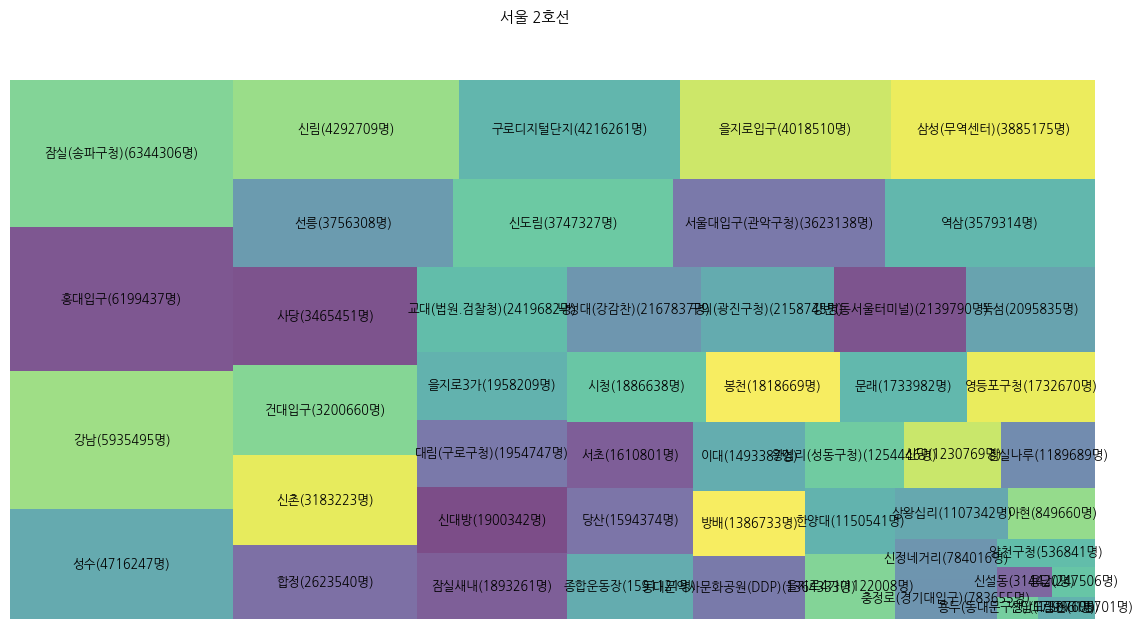

In [64]:
import squarify
plt.figure(figsize=(14,7))
squarify.plot(sizes=line2_data['total'], label=[f'{x[0]}({x[1]}명)' for x in zip(line2_data['name'],line2_data['total'])],alpha=0.7)
plt.rcParams['font.size'] = 9
plt.rcParams['text.color'] = 'black'
plt.gca().invert_yaxis() #축 뒤집기
plt.suptitle("서울 2호선")
plt.axis("off") # 인덱스 없애기
plt.savefig("./서울2호선.png")
plt.show()